CLEANING DATASET

In [4]:
import pandas as pd

df = pd.read_csv('../data/cardio_train.csv', sep=';')
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [5]:
df.isnull().sum()

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

In [7]:
df['age_years'] = (df['age'] / 365).astype(int)

In [8]:
df = df[(df['ap_hi'] >= 80) & (df['ap_hi'] <= 250)]
df = df[(df['ap_lo'] >= 40) & (df['ap_lo'] <= 200)]
df = df[(df['ap_hi'] >= df['ap_lo'])]   # systolic must be >= diastolic
df = df[(df['height'] >= 100) & (df['height'] <= 220)]
df = df[(df['weight'] >= 30) & (df['weight'] <= 200)]

In [9]:
df['gender'] = df['gender'].map({1: 0, 2: 1})  # 0 = woman, 1 = man

In [10]:
df['bmi'] = df['weight'] / ((df['height']/100) ** 2)

In [18]:
from sklearn.preprocessing import StandardScaler

num_cols = ['age_years', 'height', 'weight', 'ap_hi', 'ap_lo', 'bmi']
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[num_cols] = scaler.fit_transform(df[num_cols])

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

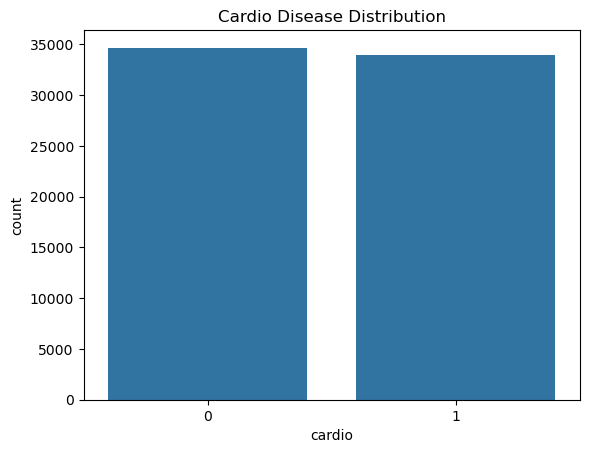

In [15]:
# distribution of target
sns.countplot(x='cardio', data=df)
plt.title('Cardio Disease Distribution')
plt.show()


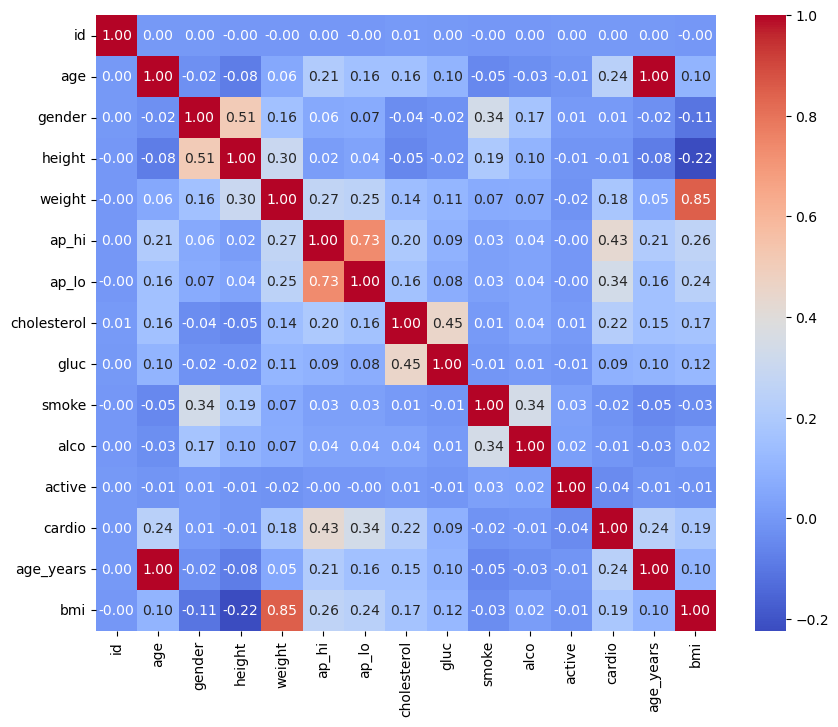

In [16]:
# correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

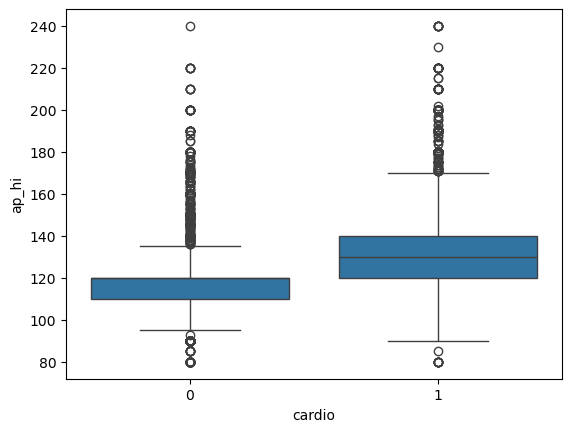

In [17]:
# boxplot to check outliers
sns.boxplot(x='cardio', y='ap_hi', data=df)
plt.show()

In [19]:
df.to_csv('../data/cardio_cleaned.csv', index=False)